In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

import time

from sklearn.preprocessing import LabelEncoder
from data_load_utils import load_image, load_data, create_data_frame

import PIL
from PIL import Image

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms

In [2]:
from torchvision.models import ResNet50_Weights

## Loading & Preparing Data for ResNet50

In [3]:
training_dir = "./data/train"
testing_dir = "./data/test"

In [8]:
weights = ResNet50_Weights.IMAGENET1K_V2

In [9]:
transform = weights.transforms()

In [10]:
train_dataset = ImageFolder(root=training_dir, transform=transform)

In [23]:
train_loader = DataLoader(train_dataset, batch_size = 10, shuffle = True)

## Loading & Training ResNet50

In [12]:
model = torchvision.models.resnet50(weights = weights, progress = True)

In [13]:
for param in model.parameters():
    param.requires_grad = False

In [14]:
num_ftrs = model.fc.in_features

In [15]:
model.fc = nn.Linear(num_ftrs, 7)

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [32]:
losses = []
scores = {}
epoch_count = 0

In [39]:
epochs = 1

start_time = time.time()

for epoch in range(epochs):
    model.train()
    corrects = 0
    wrongs = 0 
    running_loss = 0
    for b, (X_train, y_train) in enumerate(train_loader):
        batch = b+1
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)

        predicted = torch.argmax(y_pred, dim = 1)

        corrects += (predicted == y_train).sum().item()
        wrongs += (predicted != y_train).sum().item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if b%100 == 0:
            print(f"Epoch: {epoch}/{epochs} Batch: {batch} Current Loss: {running_loss/batch}")
    
    scores[epoch_count] = {
        "corrects": corrects,
        "wrongs": wrongs,
        "accuracy": corrects/(wrongs+corrects),
        "loss": running_loss/batch
    }
    epoch_count += 1
    print(f"Epoch: {epoch}. Current Accuracy: {corrects/(wrongs+corrects)}")
    losses.append(running_loss/batch)

end_time = time.time()
total_time = (end_time-start_time)/60
print(f"Training took {total_time} minutes")
        

Epoch: 0/1 Batch: 1 Current Loss: 1.5392253398895264
Epoch: 0/1 Batch: 101 Current Loss: 1.4211554745636363
Epoch: 0/1 Batch: 201 Current Loss: 1.3953515412795603
Epoch: 0/1 Batch: 301 Current Loss: 1.4003767228601778
Epoch: 0/1 Batch: 401 Current Loss: 1.4191749158345552
Epoch: 0/1 Batch: 501 Current Loss: 1.4154548021609674
Epoch: 0/1 Batch: 601 Current Loss: 1.4197723524344343
Epoch: 0/1 Batch: 701 Current Loss: 1.4179917823911223
Epoch: 0/1 Batch: 801 Current Loss: 1.4238616237033173
Epoch: 0/1 Batch: 901 Current Loss: 1.423158986123897
Epoch: 0/1 Batch: 1001 Current Loss: 1.4183795379472899
Epoch: 0/1 Batch: 1101 Current Loss: 1.4182213794416345
Epoch: 0/1 Batch: 1201 Current Loss: 1.4141921807486846
Epoch: 0/1 Batch: 1301 Current Loss: 1.4143098061310155
Epoch: 0/1 Batch: 1401 Current Loss: 1.4200919551733644
Epoch: 0/1 Batch: 1501 Current Loss: 1.422518596142471
Epoch: 0/1 Batch: 1601 Current Loss: 1.426219285688573
Epoch: 0/1 Batch: 1701 Current Loss: 1.430459370408459
Epoch: 0

In [54]:
#Saving Model
torch.save(model, "./models/resnet50_fine_tuned.pth")

In [55]:
#Saving Model Params in order to make continued training possible
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()
}, "./models/resnet50_checkpoint.pth")

In [56]:
#Saving Scores Dict in order to keep track of model improvements in case of continued training
with open("./models/resnet_50_scores.pkl", "wb") as f:
    pickle.dump(scores, f)

In [43]:
scores.values()

dict_values([{'corrects': 11447, 'wrongs': 17262, 'accuracy': 0.3987251384583232, 'loss': 1.5604493197810148}, {'corrects': 12058, 'wrongs': 16651, 'accuracy': 0.4200076631021631, 'loss': 1.4986057877540588}, {'corrects': 12531, 'wrongs': 16178, 'accuracy': 0.43648333275279527, 'loss': 1.4705945991838656}, {'corrects': 12698, 'wrongs': 16011, 'accuracy': 0.4423003239402278, 'loss': 1.4578993632709552}, {'corrects': 12760, 'wrongs': 15949, 'accuracy': 0.44445992545891533, 'loss': 1.44521168957019}, {'corrects': 12922, 'wrongs': 15787, 'accuracy': 0.4501027552335505, 'loss': 1.4368831186458981}])

In [44]:
accuracies = []
for v in scores.values():
    accuracies.append(v["accuracy"])

In [45]:
accuracies

[0.3987251384583232,
 0.4200076631021631,
 0.43648333275279527,
 0.4423003239402278,
 0.44445992545891533,
 0.4501027552335505]

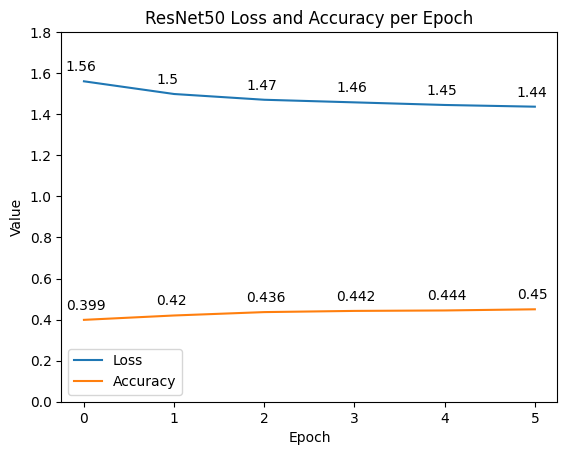

In [53]:
plt.plot(range(len(losses)), losses, label = "Loss")
plt.plot(range(len(accuracies)), accuracies, label = "Accuracy")
for i, v in enumerate(losses):
    plt.text(i -0.2, v+0.05, f"{v:.3}")

for i, v in enumerate(accuracies):
    plt.text(i-0.2, v+0.05, f"{v:.3}")
plt.ylim(0,1.8)
plt.legend()
plt.title("ResNet50 Loss and Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.savefig("./graphics/ResNet_Loss_Accuracy")
plt.show()

In [58]:
"b"

'b'